In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
dados = pd.read_csv(r"e:\PÓS GRADUAÇÃO\Fase 2 - Machine Learning and Times Series\2. Machine Learning com Python\Aula 3. Feature Engineering\data.csv", sep=",")

In [3]:
dados.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [7]:
dados.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

<Axes: >

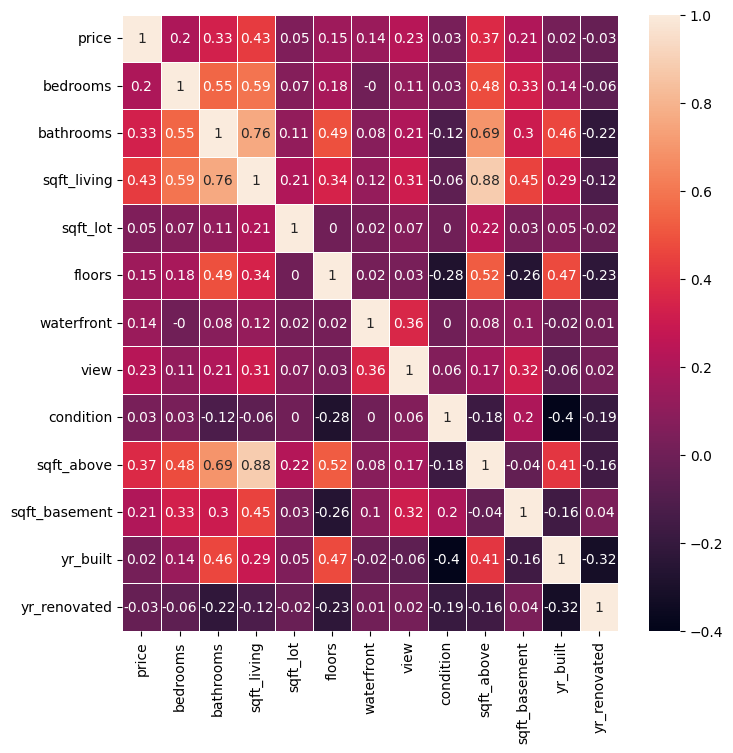

In [11]:
# Select only numeric columns
numeric_dados = dados.select_dtypes(include=[np.number])

correlation_matrix = numeric_dados.corr().round(2)

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data = correlation_matrix, annot=True, linewidths=.5, ax=ax)

<Axes: xlabel='sqft_living', ylabel='price'>

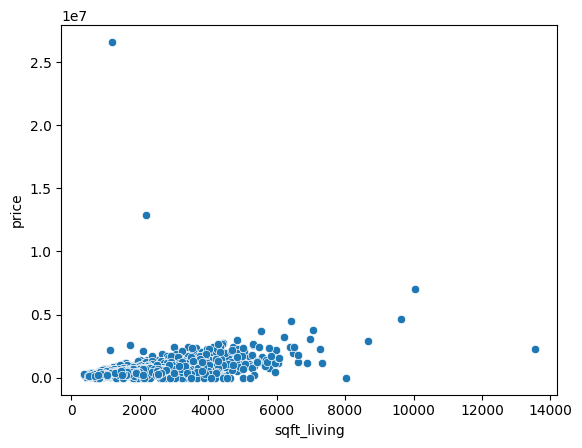

In [13]:
x = numeric_dados[["sqft_living","bathrooms"]].values
y = numeric_dados["price"].values

sns.scatterplot(data = dados, x= "sqft_living", y="price")

<Axes: xlabel='bathrooms', ylabel='price'>

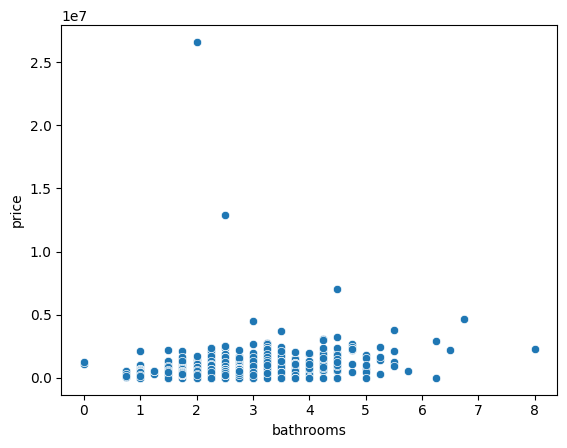

In [15]:
sns.scatterplot(data = dados, x= "bathrooms", y="price")

<Axes: >

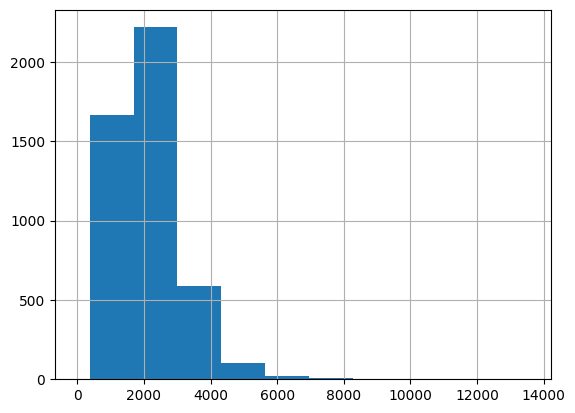

In [16]:
hist_variaveis = pd.DataFrame(dados, columns=["sqft_living", "bathrooms"])
hist_variaveis.sqft_living.hist()
hist_variaveis.bathrooms.hist()

## Padronização

In [17]:
scaler = StandardScaler()

x_std = scaler.fit_transform(x)

In [18]:
x_std

array([[-0.82997105, -0.84320364],
       [ 1.56852826,  0.43280154],
       [-0.21736733, -0.20520105],
       ...,
       [ 0.90400897,  0.43280154],
       [-0.05123751, -0.20520105],
       [-0.67422434,  0.43280154]], shape=(4600, 2))

<Axes: >

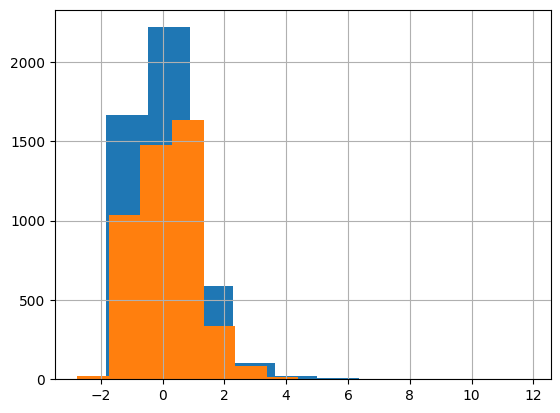

In [20]:
x_std = pd.DataFrame(x_std, columns=["sqtd_living", "bathrooms"])
x_std.sqtd_living.hist()
x_std.bathrooms.hist()